<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

# OBJECTIF DE CE NOTEBOOK
Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner code, texte et graphiques.

Cet outil est formidable pour plusieurs raisons:

+ Il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'une instruction, de la corriger si nécessaire.
+ Il permet aussi de rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ Il est possible d'ajouter des graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandé.

Et gardez à l'esprit qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



# Etape 1 - Importation des librairies et chargement des fichiers

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [12]:
import pandas as pd
#Importation de la librairie plotly express
import plotly.express as px

In [13]:
#Trouver dans Google l'instruction permettant d'afficher toutes les colonnes d'un dataframe
pd.set_option('display.max_columns', None)
#Saisir dans Google les mots clés "display all columns dataframe Pandas" par exemple.
#Dans les résultats de la recherche, privilégier les solutions provenant de Stack Overflow ou Medium

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [15]:
#Importation du fichier web.xlsx
df_web = pd.read_excel('/content/drive/MyDrive/projet6/web.xlsx')
#Importation du fichier erp.xlsx
df_erp=pd.read_excel('/content/drive/MyDrive/projet6/erp.xlsx')
#Importation du fichier liaison.xlsx
df_liaison=pd.read_excel('/content/drive/MyDrive/projet6/liaison.xlsx')

/usr/local/lib/python3.13/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.13/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.13/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


#Etape 2 - Analyse exploratoire des fichiers

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

In [16]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_erp.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_erp.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


In [17]:
#Consulter le nombre de colonnes
print("Nombre de colonnes :", df_erp.shape[1],"\n")
#La nature des données dans chacune des colonnes
print("Types de données :\n", df_erp.dtypes)
#Le nombre de valeurs présentes dans chacune des colonnes
print("\nNombre de valeurs par colonne :\n", df_erp.count())

Nombre de colonnes : 6 

Types de données :
 product_id          int64
onsale_web          int64
price             float64
stock_quantity      int64
stock_status       object
purchase_price    float64
dtype: object

Nombre de valeurs par colonne :
 product_id        825
onsale_web        825
price             825
stock_quantity    825
stock_status      825
purchase_price    825
dtype: int64


In [18]:
#Afficher les 5 premières lignes de la table
df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [19]:
#Vérifier si il y a des lignes en doublon dans la colonne product_id
df_erp.loc[df_erp['product_id'].duplicated(keep=False),:]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price


In [20]:
#Afficher les valeurs distinctes de la colonne stock_status
df_erp['stock_status'].value_counts()
#À quelle(s) autre(s) colonne(s) sont-elles liées ?


,count
stock_status,
instock,733
outofstock,92


In [21]:
#Création d'une colonne "stock_status_2"
df_erp['stock_status_2']='instock'
#La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
#Si la valeur de la colonne "stock_quantity" est nulle, renseigner "outofstock" sinon mettre "instock"
df_erp.loc[df_erp['stock_quantity'] == 0, 'stock_status_2'] = 'outofstock'
df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
0,3847,1,24.2,16,instock,12.88,instock
1,3849,1,34.3,10,instock,17.54,instock
2,3850,1,20.8,0,outofstock,10.64,outofstock
3,4032,1,14.1,26,instock,6.92,instock
4,4039,1,46.0,3,outofstock,23.77,instock


In [22]:
#Vérifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 à 2
#La comparaison de 2 colonnes peut se réaliser simplement avec l'instruction ci-dessous:
df_erp["stock_status"] == df_erp["stock_status_2"]

#Le résultat est l'affichage de True ou False pour chacune des lignes du dataset
#C'est un bon début, mais difficile à exploiter

,0
0,True
1,True
2,True
3,True
4,False
...,...
820,True
821,True
822,True
823,True


In [23]:
#Mais il est possible de synthétiser ce résultat en effectuant la somme de cette colonne:
#True vaut 1 et False 0
#Nous devrions obtenir la somme de 824 qui correspond au nombre de lignes dans ce dataset
(df_erp["stock_status"] == df_erp["stock_status_2"]).value_counts()

,count
True,821
False,4


In [24]:
#Si les colonnes ne sont absolument pas identiques ligne à ligne alors identifier la ligne en écart
##Dans ce cas je vous donne ce lien pour apprendre à réaliser des filtres dans Pandas:
##https://bitbucket.org/hrojas/learn-pandas/src/master/
##Lesson 3
df_erp.loc[df_erp["stock_status"] != df_erp["stock_status_2"],:]


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
4,4039,1,46.0,3,outofstock,23.77,instock
398,4885,1,18.7,0,instock,9.66,outofstock
449,4973,0,10.0,-10,outofstock,4.96,instock
573,5700,1,44.5,-1,outofstock,22.30,instock


In [25]:
#Corriger la ou les données incohérentes
df_erp.loc[df_erp['stock_quantity'] <= 0, 'stock_status_2'] = 'outofstock'
df_erp.loc[df_erp['stock_quantity'] > 0, 'stock_status_2'] = 'instock'
df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
0,3847,1,24.2,16,instock,12.88,instock
1,3849,1,34.3,10,instock,17.54,instock
2,3850,1,20.8,0,outofstock,10.64,outofstock
3,4032,1,14.1,26,instock,6.92,instock
4,4039,1,46.0,3,outofstock,23.77,instock


In [26]:
#Vérification en utilisant le même code que plus haut pour afficher les problèmes
df_erp.loc[df_erp["stock_status"] != df_erp["stock_status_2"],:]
df_erp.head()


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
0,3847,1,24.2,16,instock,12.88,instock
1,3849,1,34.3,10,instock,17.54,instock
2,3850,1,20.8,0,outofstock,10.64,outofstock
3,4032,1,14.1,26,instock,6.92,instock
4,4039,1,46.0,3,outofstock,23.77,instock


In [27]:
#k affecter les valeurs de stock statut 2 à stock status et supprimer la colonne stock status 2
df_erp["stock_status"] = df_erp["stock_status_2"]
df_erp.drop(columns=['stock_status_2'],inplace=True)
df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,instock,23.77


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.1 - Analyse de la variable PRIX</h3>
</div>

In [28]:
###############
## LES PRIX  ##
###############

#Vérification des prix: Y a t-il des prix non renseignés, négatifs ou nuls?
#Afficher le ou les prix non renseignés dans la colonne "price"
print("Nombres d'articles avec un prix non renseigné: {}".format(df_erp["price"].isna().sum())) #Saisir l'instruction manquante dans la fonction format
#Afficher le prix minimum de la colonne "price"
print('Le prix minimum de la colonne price :',df_erp['price'].min())
#Afficher le prix maximum de la colonne "price"
print('Le prix maximum de la colonne price :',df_erp['price'].max())
#Afficher les prix inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
print('Les prix inférieurs à 0:','\n')
df_erp.loc[df_erp['price']<0,:]

Nombres d'articles avec un prix non renseigné: 0
Le prix minimum de la colonne price : -20.0
Le prix maximum de la colonne price : 225.0
Les prix inférieurs à 0: 



,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
151,4233,0,-20.0,0,outofstock,10.33
469,5017,0,-8.0,0,outofstock,4.34
739,6594,0,-9.1,19,instock,4.61


In [29]:
#k Affecter les prix negatif dans une nouvelle variable et puis les supprimer
df_erp_price_neg=df_erp.loc[df_erp['price']<0,:]
df_erp.drop(df_erp[df_erp["price"] < 0].index, inplace=True)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.2 - Analyse de la variable STOCK</h3>
</div>

In [30]:
#######################
### stock_quantity  ###
#######################

#Afficher le ou les quantités non renseignés dans la colonne "stock_quantity"
print("Nombres d'articles avec une quantité de stock non renseigné: {}".format(df_erp["stock_quantity"].isna().sum()))
#Afficher la quantité minimum de la colonne "stock_quantity"
print('La quantité minimum de la colonne "stock_quantity :',df_erp['stock_quantity'].min())
#Afficher la quantité maximum de la colonne "stock_quantity"
print('La quantité maximum de la colonne stock_quantity :',df_erp['stock_quantity'].max())
#Afficher les stocks inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
print('Les stocks inférieurs à 0:','\n')
df_erp.loc[df_erp['stock_quantity']<0,:]

Nombres d'articles avec une quantité de stock non renseigné: 0
La quantité minimum de la colonne "stock_quantity : -10
La quantité maximum de la colonne stock_quantity : 145
Les stocks inférieurs à 0: 



,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
449,4973,0,10.0,-10,outofstock,4.96
573,5700,1,44.5,-1,outofstock,22.30


In [31]:
#k Affecter les prix stock negatif dans une nouvelle variable et puis les supprimer
df_erp_stock_quantity_neg=df_erp.loc[df_erp['stock_quantity']<0,:]
df_erp.drop(df_erp[df_erp["stock_quantity"] < 0].index, inplace=True)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.3 - Analyse de la variable ONSALE_WEB</h3>
</div>

In [32]:
#Afficher le ou les quantités non renseignés dans la colonne "onsale_web"
print("Nombres d'articles non renseigné: {}".format(df_erp["onsale_web"].isna().sum()))
#Vérification de la colonne onsale_web et des valeurs qu'elle contient. Que signifient-elles?
df_erp['onsale_web'].value_counts()

Nombres d'articles non renseigné: 0


,count
onsale_web,
1,715
0,105


In [33]:
#k filtre des produit disponible en stock pour voir si un produit disponible est bien proposé à la vente
df_erp_instock=df_erp.loc[df_erp['stock_status']=='instock' ,: ]
df_erp_instock['onsale_web'].value_counts()

,count
onsale_web,
1,668
0,64


In [34]:
#Quelles sont les colonnes à conserver selon vous?


In [35]:
#Supprimer la colonne comportant le libellé "stock_status_2" car elle est redondante
#avec la colonne "stock_status".


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.4 - Analyse de la variable prix d'achat</h3>
</div>

In [36]:
######################
##   prix d'achat   ##
######################

#Vérification de la colonne purchase_price :
#Afficher le ou les prix non renseignés dans la colonne "purchase_price"
print("Nombre de prix non renseignés dans la colonne purchase_price: {}".format(df_erp["purchase_price"].isna().sum()))
#Afficher le prix minimum de la colonne "purchase_price"
print('Le prix minimum de la colonne purchase_price :',df_erp['purchase_price'].min())
#Afficher le prix maximum de la colonne "purchase_price"
print('Le prix maximum de la colonne purchase_price :',df_erp['purchase_price'].max())

Nombre de prix non renseignés dans la colonne purchase_price: 0
Le prix minimum de la colonne purchase_price : 2.74
Le prix maximum de la colonne purchase_price : 137.81


Identifier et traiter les incohérences de prix afin de garantir la cohérence économique des analyses de marge.

In [37]:
# Calculer le prix HT
df_erp['prix_ht'] = df_erp['price'] / 1.20
#Comparaison du prix de vente HT avec le coût d’achat HT
df_prix_incoherent = df_erp[df_erp['prix_ht'] < df_erp['purchase_price'] ]
#Dataset nettoyé (on garde seulement les cohérentes)
df_erp.drop (df_prix_incoherent.index,inplace=True)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>


In [38]:
#Dimension du dataset
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_web.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_web.shape[1]))

Le tableau comporte 1513 observation(s) ou article(s)
Le tableau comporte 29 colonne(s)


In [39]:
#Consulter le nombre de colonnes
print("Nombre de colonnes :", df_web.shape[1],"\n")
#La nature des données dans chacune des colonnes
print("Types de données :\n", df_web.dtypes)
#Le nombre de valeurs présentes dans chacune des colonnes
print("\nNombre de valeurs par colonne :\n", df_web.count())

Nombre de colonnes : 29 

Types de données :
 sku                              object
virtual                           int64
downloadable                      int64
rating_count                      int64
average_rating                  float64
total_sales                     float64
tax_status                       object
tax_class                       float64
post_author                     float64
post_date                datetime64[ns]
post_date_gmt            datetime64[ns]
post_content                    float64
product_type                     object
post_title                       object
post_excerpt                     object
post_status                      object
comment_status                   object
ping_status                      object
post_password                   float64
post_name                        object
post_modified            datetime64[ns]
post_modified_gmt        datetime64[ns]
post_content_filtered           float64
post_parent                     fl

In [40]:
#Selon vous, quelles sont les colonnes à conserver ?


In [41]:
#Si vous avez défini des colonnes à supprimer, effectuer l'opération
df_web.drop(columns=["tax_class", "post_content","post_password","post_content_filtered"], inplace=True)

In [42]:
#Visualisation des valeurs de la colonne sku
sk=df_web['sku'].value_counts()
sk

,count
sku,
14569,2
11862,2
16057,2
14692,2
16295,2
...,...
15575,2
12869,2
15526,2


In [43]:
df_web['post_type'].value_counts()

,count
post_type,
product,716
attachment,714


In [44]:
df_web['post_mime_type'].value_counts()

,count
post_mime_type,
image/jpeg,714


In [45]:
#les doublons de sku viennent du fait qu’il existe 2 types de lignes pour un même produit
#supprimer celles de type image
df_web_type_image = df_web[df_web["post_type"] == "attachment"]
df_web = df_web[df_web["post_type"] != "attachment"]

In [46]:
#detecter les doublons
df_web.loc[df_web.duplicated(keep=False),:]

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
8,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
20,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
30,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
37,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
41,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1384,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1429,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1432,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1445,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN


In [47]:
#Quelles sont les valeurs qui ne semblent pas respecter la régle de codification?


In [48]:
#Si vous avez identifié des codes articles ne respectant pas la régle de codification, consultez-les


In [49]:
#Identifier les lignes sans code article
df_sans_sku=df_web.loc[df_web['sku'].isna(),:]
df_sans_sku

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,post_author,post_date,post_date_gmt,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_name,post_modified,post_modified_gmt,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
8,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
20,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
30,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
37,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
41,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1384,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1429,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1432,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1445,NaN,0,0,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN


In [50]:
#Les lignes sans code article semblent être toutes non renseignées
#Pour s'en assurer, réaliser les étapes suivantes:
#1 - Créer un dataframe avec uniquement les lignes sans code article
#2 - Utiliser la fonction df.info() sur ce nouveau dataframe pour observer le nombre de valeurs renseignées dans chacune des colonnes
df_sans_sku.info()
#3 - Que constatez-vous?

<class 'pandas.core.frame.DataFrame'>
Index: 85 entries, 8 to 1457
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   sku                0 non-null      object        
 1   virtual            85 non-null     int64         
 2   downloadable       85 non-null     int64         
 3   rating_count       85 non-null     int64         
 4   average_rating     2 non-null      float64       
 5   total_sales        2 non-null      float64       
 6   tax_status         2 non-null      object        
 7   post_author        2 non-null      float64       
 8   post_date          2 non-null      datetime64[ns]
 9   post_date_gmt      2 non-null      datetime64[ns]
 10  product_type       2 non-null      object        
 11  post_title         2 non-null      object        
 12  post_excerpt       2 non-null      object        
 13  post_status        2 non-null      object        
 14  comment_status 

In [51]:
# k suppression des ligne sans SKU
df_web.dropna(subset=["sku"], inplace=True)
# k Vérification après suppression
df_web["sku"].isna().sum()

np.int64(0)

In [52]:
#Pour les codes articles identifiés, réaliser une analyse et définir l'action à entreprendre

In [53]:
#La clé pour chaque ligne est-elle unique? autrement dit, y a-t-il des doublons?

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier liaison.xlsx</h3>
</div>

In [54]:
#Dimension du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_liaison.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_liaison.shape[1]))
#Nombre d'observations

#Nombre de caractéristiques


Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 2 colonne(s)


In [55]:
#Consulter le nombre de colonnes
print("Nombre de colonnes :", df_liaison.shape[1],"\n")
#La nature des données dans chacune des colonnes
print("Types de données :\n", df_liaison.dtypes)
#Le nombre de valeurs présentes dans chacune des colonnes
print("\nNombre de valeurs par colonne :\n", df_liaison.count())

Nombre de colonnes : 2 

Types de données :
 id_web        object
product_id     int64
dtype: object

Nombre de valeurs par colonne :
 id_web        734
product_id    825
dtype: int64


In [56]:
#Les valeurs de la colonne "product_id" sont-elles toutes uniques?
df_liaison.loc[df_liaison['product_id'].duplicated(keep=False),:]

,id_web,product_id


In [57]:
#Les valeurs de la colonne "id_web" sont-elles toutes uniques?
df_liaison.loc[df_liaison['id_web'].duplicated(keep=False),:]

,id_web,product_id
19,NaN,4055
49,NaN,4090
50,NaN,4092
119,NaN,4195
131,NaN,4209
...,...,...
817,NaN,7196
818,NaN,7200
819,NaN,7201
820,NaN,7203


In [58]:
#Avons-nous des articles sans correspondance?
df_liaison_sans_correspondance=df_liaison.loc[df_liaison['id_web'].isnull(),:]
df_liaison_sans_correspondance

,id_web,product_id
19,NaN,4055
49,NaN,4090
50,NaN,4092
119,NaN,4195
131,NaN,4209
...,...,...
817,NaN,7196
818,NaN,7200
819,NaN,7201
820,NaN,7203


In [59]:
# k suppression des ligne sans correspondance
df_liaison.dropna(subset=['id_web'], inplace=True)
df_liaison.loc[df_liaison['id_web'].duplicated(keep=False),:]

,id_web,product_id


#Etape 3 - Jonction des fichiers

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction du fichier df_erp et df_liaison</h3>
</div>

In [60]:
#Fusion des fichiers df_erp et df_liaison
jointure_erp_liaison=pd.merge(df_erp,df_liaison,on=['product_id'],how='inner')
jointure_erp_liaison

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,prix_ht,id_web
0,3847,1,24.2,16,instock,12.88,20.166667,15298
1,3849,1,34.3,10,instock,17.54,28.583333,15296
2,3850,1,20.8,0,outofstock,10.64,17.333333,15300
3,4032,1,14.1,26,instock,6.92,11.750000,19814
4,4039,1,46.0,3,instock,23.77,38.333333,19815
...,...,...,...,...,...,...,...,...
726,7023,1,27.5,23,instock,14.21,22.916667,15891
727,7025,1,69.0,8,instock,34.22,57.500000,15887
728,7247,1,54.8,6,instock,27.18,45.666667,13127-1
729,7329,0,26.5,14,instock,13.42,22.083333,14680-1


In [61]:
#Y a t-il des lignes ne "matchant" pas entre les 2 fichiers?
#k Une jointure externe avec indicateur est réalisée afin d’identifier les lignes ne disposant pas de correspondance entre les fichiers ERP et liaison.
#grace à indicator=True Pandas ajoute une nouvelle colonne automatique appelée _merge
test_match = pd.merge(df_erp,df_liaison,on="product_id",how="outer",indicator=True)
test_match["_merge"].value_counts()


,count
_merge,
both,731
left_only,85
right_only,3


In [62]:
#Produits ERP sans correspondance (left_only)
test_match.loc[test_match["_merge"] == "left_only", ["product_id"]]

,product_id
19,4055
49,4090
50,4092
119,4195
131,4209
...,...
811,7195
812,7200
813,7201
814,7203


In [63]:
#Produits liaison sans correspondance ERP (right_only)
test_match.loc[test_match["_merge"] == "right_only", ["product_id", "id_web"]]

,product_id,id_web
209,4355,12589
390,4864,15154
570,5700,14736


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction du fichier df_merge et df_web</h3>
</div>

In [64]:
#Fusionner les datasets df_merge et df_web
df_merge=pd.merge(jointure_erp_liaison, df_web, left_on="id_web",right_on="sku",how="inner")

In [65]:
#Avons-nous des lignes sans correspondance?
test_match2 = pd.merge(jointure_erp_liaison,df_web,left_on="id_web",right_on="sku",how="outer",indicator=True)
test_match2["_merge"].value_counts()

,count
_merge,
both,712
left_only,19
right_only,2


In [66]:
#Produits jointure_erp_liaison sans correspondance (left_only)
test_match2.loc[test_match2["_merge"] == "left_only", ["id_web"]]

,id_web
81,12601
127,13577
139,13771
180,14360
185,14377
186,14379
212,14648
218,14689
224,14715
227,14730


In [67]:
#Produits web sans correspondance  (right_only)
test_match2.loc[test_match2["_merge"] == "right_only", ["sku"]]

,sku
79,12589
228,14736


#Etape 4 - Analyse univariée des prix

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - Exploration par la visualisation de données</h3>
</div>

<Axes: >

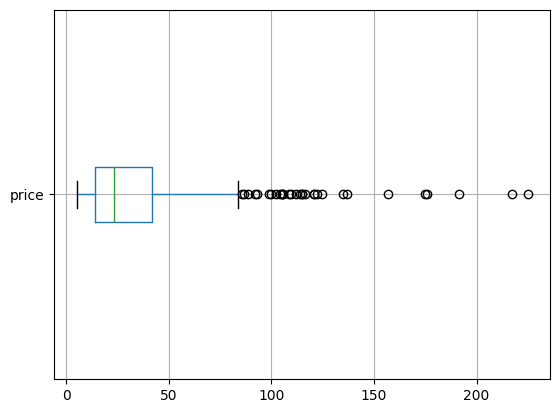

In [68]:
#Création d'une boîte à moustache de la répartition des prix grâce à Pandas
df_merge.boxplot(column=['price'],vert=False)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - Exploration par l'utilisation de méthodes statistiques</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.1 - Identification par le Z-index</h3>
</div>

In [69]:
#Calculer la moyenne du prix
moyenne=df_merge['price'].mean()

In [70]:
#Calculer l'écart-type du prix
ecart_type=df_merge['price'].std()

In [71]:
#Calculer le Z-score
df_merge['Z_score'] = (df_merge['price'] - moyenne) / ecart_type

In [72]:
#Quel est le seuil prix dont le z-score est supérieur à 3?
seuil_prix=moyenne + 3 * ecart_type
seuil_prix

np.float64(115.20870284354015)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.2 - Identification par l'intervalle interquartile</h3>
</div>

In [73]:
#Utilisation de la fonction "describe" de Pandas pour l'étude des mesures de dispersion
df_merge.describe()

,product_id,onsale_web,price,stock_quantity,purchase_price,prix_ht,virtual,downloadable,rating_count,average_rating,total_sales,post_author,post_date,post_date_gmt,post_modified,post_modified_gmt,post_parent,menu_order,comment_count,Z_score
count,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.0,712.0,712.0,712.0,712.000000,712.000000,712,712,712,712,712.0,712.0,712.0,7.120000e+02
mean,5032.571629,0.998596,32.344242,23.375000,16.811348,26.953535,0.0,0.0,0.0,0.0,8.066011,1.998596,2018-08-22 04:18:52.880617984,2018-08-22 02:50:03.667134720,2020-06-20 21:59:27.613764352,2020-06-20 20:05:56.939606784,0.0,0.0,0.0,7.983626e-17
min,3847.000000,0.000000,5.200000,0.000000,2.740000,4.333333,0.0,0.0,0.0,0.0,0.000000,1.000000,2018-02-08 12:58:52,2018-02-08 11:58:52,2018-02-20 15:19:23,2018-02-20 14:19:23,0.0,0.0,0.0,-9.827219e-01
25%,4279.250000,1.000000,14.087500,9.000000,7.235000,11.739583,0.0,0.0,0.0,0.0,5.000000,2.000000,2018-02-27 14:12:06.750000128,2018-02-27 13:12:06.750000128,2020-06-19 10:07:33,2020-06-19 08:07:33,0.0,0.0,0.0,-6.609616e-01
50%,4796.000000,1.000000,23.450000,20.000000,12.280000,19.541667,0.0,0.0,0.0,0.0,8.000000,2.000000,2018-04-19 14:52:10,2018-04-19 12:52:10,2020-08-04 09:30:06.500000,2020-08-04 07:30:06.500000,0.0,0.0,0.0,-3.220044e-01
75%,5711.250000,1.000000,42.025000,30.000000,22.022500,35.020833,0.0,0.0,0.0,0.0,11.000000,2.000000,2019-01-31 14:43:44.750000128,2019-01-31 13:43:44.750000128,2020-08-25 10:42:32,2020-08-25 08:42:32,0.0,0.0,0.0,3.504793e-01
max,7338.000000,1.000000,225.000000,145.000000,137.810000,187.500000,0.0,0.0,0.0,0.0,36.000000,2.000000,2020-07-20 11:00:00,2020-07-20 09:00:00,2020-08-27 18:55:03,2020-08-27 16:55:03,0.0,0.0,0.0,6.974851e+00
std,790.817952,0.037477,27.621487,22.061188,14.671715,23.017906,0.0,0.0,0.0,0.0,4.156214,0.037477,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.000000e+00


In [74]:
#Définir un seuil pour les articles "outliers" en prix
#l’écart interquartile

Q1 = df_merge["price"].quantile(0.25)
Q3 = df_merge["price"].quantile(0.75)
IQ = Q3 - Q1
seuil_bas= Q1- (1.5 * IQ)
seuil_haut=Q3 + (1.5 * IQ)
seuil_bas, seuil_haut

(np.float64(-27.81875), np.float64(83.93125))

In [75]:
#Définir le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"
outliers_prix = df_merge[(df_merge["price"] > seuil_haut)]
nb_outliers = outliers_prix.shape[0]
proportion = nb_outliers / len(df_merge)
print("Nombre d’articles outliers :", nb_outliers)
print("Proportion d’articles outliers :", round(proportion, 4))
print("Proportion (%) :", round(proportion * 100, 2), "%")

Nombre d’articles outliers : 31
Proportion d’articles outliers : 0.0435
Proportion (%) : 4.35 %


In [76]:
#Selon vous, ces outliers sont-ils justifiés ? Comment le démontrer si cela est possible ?
df_outliers=df_merge.loc[df_merge["price"] > seuil_haut,['post_name','product_type','price']].sort_values(by='price',ascending=False).head(10)
df_outliers

,post_name,product_type,price
199,champagne-egly-ouriet-grand-cru-millesime-2008,Champagne,225.0
425,david-duband-charmes-chambertin-grand-cru-2014,Vin,217.5
585,coteaux-champenois-egly-ouriet-ambonnay-rouge-...,Champagne,191.3
217,cognac-frapin-vip-xo,Cognac,176.0
551,camille-giroud-clos-de-vougeot-2016,Vin,175.0
220,cognac-frapin-chateau-de-fontpinot-1989-20-ans,Cognac,157.0
380,domaine-des-croix-corton-charlemagne-grand-cru...,Vin,137.0
640,champagne-gosset-celebris-vintage-2007,Champagne,135.0
510,domaine-weinbach-gewurztraminer-gc-furstentum-...,Vin,124.8
601,wemyss-malts-single-cask-scotch-whisky-choc-n-...,Whisky,122.0


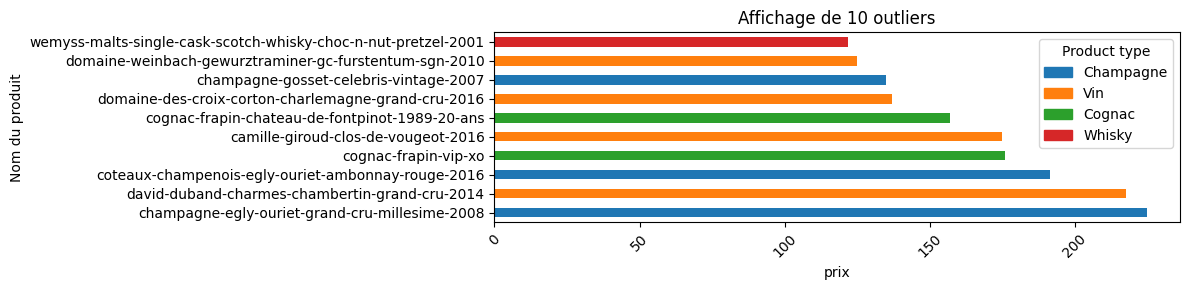

In [77]:
import matplotlib.pyplot as plt
# Associer une couleur à chaque product_type
product_types = df_outliers['product_type'].unique()
colors = plt.cm.tab10.colors
color_map = {pt: colors[i % len(colors)] for i, pt in enumerate(product_types)}
# Graphique en barres
df_outliers.plot(x='post_name', y='price', kind='barh', figsize=(12,3),legend=False,color=[color_map[pt] for pt in df_outliers['product_type']])
plt.xlabel("prix")
plt.ylabel("Nom du produit")
plt.title("Affichage de 10 outliers")
plt.xticks(rotation=45)
#  Légende manuelle
handles = [ plt.Rectangle((0,0),1,1, color=color_map[pt])for pt in product_types]
plt.legend(handles, product_types, title="Product type")
plt.tight_layout()
plt.show()

#Etape 5 - Analyse univariée du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivariée  

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse des ventes en CA</h3>
</div>

In [78]:
##############################
# Calculer le CA du site web #
##############################
#Créer une colonne calculant le CA par article
df_merge['ca_par_article']=df_merge['price']*df_merge['total_sales']
#Calculer la somme de la colonne "ca_par_article"
ca_total=df_merge['ca_par_article'].sum()
#Ce résultat correspond au chiffre d'affaire du site web
print("Chiffre d’affaires total du site web :", round(ca_total, 2))

Chiffre d’affaires total du site web : 143324.1


In [79]:
###############################
# Palmarès des articles en CA #
###############################

#Effectuer le tri dans l'ordre décroissant du CA du dataset df_merge
df_merge.sort_values('ca_par_article',ascending=False,inplace=True)
#Réinitialiser l'index du dataset par un reset_index
df_merge.reset_index(drop=True,inplace=True)
#Afficher les 20 premiers articles en CA
top20_ca=df_merge.head(20)

In [80]:
#Graphique en barre des 20 premiers articles avec plotly express
import plotly.express as px
# Graphique en barres
fig = px.bar(top20_ca,y='post_name',x='ca_par_article',orientation='h', title="Top 20 des articles par chiffre d’affaires")
fig.update_layout(xaxis_title_font=dict(size=22),yaxis_title_font=dict(size=22),xaxis_tickfont=dict(size=18),yaxis_tickfont=dict(size=14),title_font=dict(size=28))
fig.update_layout()
fig.show()

In [81]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part du CA de la ligne dans le dataset
df_merge['part_ca']=df_merge['ca_par_article']/ca_total
#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_merge['part_ca_cumul']=df_merge['part_ca'].cumsum()
#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% du CA
nb_articles_80 = (df_merge["part_ca_cumul"] <= 0.8).sum()
#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
proportion_80 = nb_articles_80 / len(df_merge)
print("Nombre d'articles pour 80% du CA :", nb_articles_80)
print("Proportion :", round(proportion_80, 2))

Nombre d'articles pour 80% du CA : 433
Proportion : 0.61


In [82]:
import plotly.express as px
import numpy as np

df_pareto = df_merge.sort_values('ca_par_article', ascending=False).copy()
df_pareto['part_ca_cumul'] = (df_pareto['ca_par_article'] / df_pareto['ca_par_article'].sum()).cumsum()
df_pareto['rang'] = np.arange(1, len(df_pareto)+1)

fig = px.line(df_pareto, x='rang', y='part_ca_cumul', title="CA cumulé (Pareto)")
fig.add_hline(y=0.8, line_dash="dash")
fig.update_yaxes(range=[0,1], title="Part cumulée du CA")
fig.update_xaxes(title="Rang des articles")
fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Analyse des ventes en quantité</h3>
</div>

In [83]:
#####################################
# Palmarès des articles en quantité #
#####################################

#Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_merge
df_merge.sort_values('total_sales',ascending=False,inplace=True)
#Réinitialiser l'index du dataset par un reset_index
df_merge.reset_index(drop=True,inplace=True)
#Afficher les 20 premiers articles en quantité
top20_quantity=df_merge.head(20)

In [84]:
#Graphique en barre des 20 premiers articles avec plotly express
import plotly.express as px
# Graphique en barres
fig = px.bar(top20_quantity,y='post_name',x='total_sales',orientation='h', title="Top 20 des articles en quantité vendues")
fig.update_layout(xaxis_title_font=dict(size=22),yaxis_title_font=dict(size=22),xaxis_tickfont=dict(size=18),yaxis_tickfont=dict(size=14),title_font=dict(size=28))
fig.update_layout()
fig.show()

In [85]:
#############################
# Calculer le 20 / 80 en quantité#
#############################

#Créer une colonne calculant la part en quantité de la ligne dans le dataset
df_merge['part_qte']=df_merge['total_sales']/df_merge['total_sales'].sum()
#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_merge['part_qte_cumul']=df_merge['part_qte'].cumsum()
df_merge.head()
#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% des ventes en quantité
nb_articles_80_qte=(df_merge['part_qte_cumul']<=0.8).sum()
#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
proportion_80_qte=nb_articles_80_qte/len(df_merge)
print("Nombre d'articles pour 80% des ventes (quantité) :", nb_articles_80_qte)
print("Proportion :", round(proportion_80_qte, 2))

Nombre d'articles pour 80% des ventes (quantité) : 432
Proportion : 0.61


In [86]:
import plotly.express as px
import numpy as np

df_pareto = df_merge.sort_values('total_sales', ascending=False).copy()
df_pareto['part_qte_cumul'] = (df_pareto['total_sales'] / df_pareto['total_sales'].sum()).cumsum()
df_pareto['rang'] = np.arange(1, len(df_pareto)+1)

fig = px.line(df_pareto, x='rang', y='part_qte_cumul', title="Quantité cumulé (Pareto)")
fig.add_hline(y=0.8, line_dash="dash")
fig.update_yaxes(range=[0,1], title="Part cumulée en quantité")
fig.update_xaxes(title="Rang des articles")
fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.3 - Analyse des stocks</h3>
</div>

In [87]:
######################################
# Calculer le nombre de mois de stock #
######################################

#Import de numpy
import numpy as np
import matplotlib.pyplot as plt
#Création de la colonne Rotation de stock
df_merge['rotation_stock'] = np.where(df_merge['total_sales'] > 0,df_merge['stock_quantity'] / (df_merge['total_sales'] ),np.nan)
#Remplacement des "inf" par 0
df_merge['rotation_stock'].replace([np.inf, -np.inf], 0)
df_merge[df_merge['rotation_stock'] == 0][['sku','stock_quantity','total_sales']]
#Effectuer le tri dans l'ordre décroissant du nombre de mois de stock dans le dataset df_merge
df_merge.sort_values('rotation_stock',ascending=False,inplace=True)
top20 = df_merge.head(20)
#Graphique en barre du top 20 des produits qui ont le plus de mois de stock

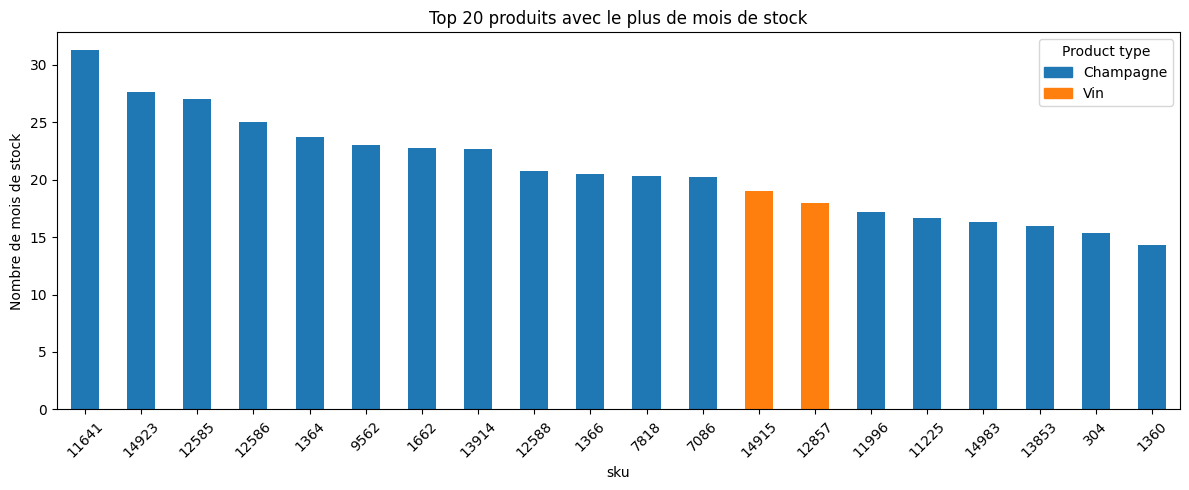

In [88]:
# Associer une couleur à chaque product_type
product_types = top20['product_type'].unique()
colors = plt.cm.tab10.colors
color_map = {pt: colors[i % len(colors)] for i, pt in enumerate(product_types)}
# Graphique en barres (top 20)
top20.plot(x='sku', y='rotation_stock', kind='bar', figsize=(12,5),legend=False,color=[color_map[pt] for pt in top20['product_type']])
plt.ylabel("Nombre de mois de stock")
plt.title("Top 20 produits avec le plus de mois de stock")
plt.xticks(rotation=45)
#  Légende manuelle
handles = [ plt.Rectangle((0,0),1,1, color=color_map[pt])for pt in product_types]
plt.legend(handles, product_types, title="Product type")
plt.tight_layout()
plt.show()

In [89]:
import plotly.express as px
# Graphique en barres
fig = px.bar(top20,y='post_name',x='rotation_stock',orientation='h', title="Top 20 produits avec le plus de mois de stock")
fig.update_layout(xaxis_title_font=dict(size=22),yaxis_title_font=dict(size=22),xaxis_tickfont=dict(size=18),yaxis_tickfont=dict(size=14),title_font=dict(size=28))
fig.update_layout()
fig.show()

In [90]:
####################################
# Valorisation des stocks en euros #
####################################

#Création de la colonne Valorisation des stocks en euros
#purchase_price → coût d’achat unitaire
df_merge['valorisation_stock_euros']=df_merge['stock_quantity']*df_merge['purchase_price']
#Calculer la somme de la colonne "Valorisation_stock_euros"
vs=df_merge['valorisation_stock_euros'].sum()
print(' Valorisation des stocks en euros :',vs)

 Valorisation des stocks en euros : 269812.51


In [91]:
##############################################
# Valorisation du nombre de produits en stock #
##############################################

#Calculer la somme de la colonne stock quantity
total_stock=df_merge['stock_quantity'].sum()
print("Nombre total de produits en stock :", total_stock)

Nombre total de produits en stock : 16643


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.4 - Analyse du taux de marge</h3>
</div>

In [92]:
############################
# Analyse du taux de marge #
############################

#Création de la colonne Prix HT
df_merge['prix_ht'] = df_merge['price'] / 1.20
#Création de la colonne Taux de marge
df_merge = df_merge[df_merge['purchase_price'] > 0]
df_merge['taux_marge'] = (df_merge['prix_ht'] - df_merge['purchase_price']) / df_merge['purchase_price']
#Afficher le prix minimum de la colonne "taux_marge"
print("Taux de marge minimum :", df_merge['taux_marge'].min())
#Afficher le prix maximum de la colonne "taux_marge"
print("Taux de marge maximum :", df_merge['taux_marge'].max())

Taux de marge minimum : 0.2949782522736259
Taux de marge maximum : 0.9141247090530442


In [93]:
#Création d'un dataframe avec les taux positifs
df_merge_positif = df_merge[df_merge['taux_marge'] >= 0]
#Afficher le prix minimum de la colonne "taux_marge"
print("Taux de marge minimum :", df_merge_positif['taux_marge'].min())
#Afficher le prix maximum de la colonne "taux_marge"
print("Taux de marge maximum :", df_merge_positif['taux_marge'].max())

Taux de marge minimum : 0.2949782522736259
Taux de marge maximum : 0.9141247090530442


In [94]:
#Création d'un dataframe avec le taux de marge moyen par type de produit
df_marge_moyenne_type=df_merge.groupby('product_type')['taux_marge'].mean().sort_values(ascending=False).reset_index()
df_marge_moyenne_type

,product_type,taux_marge
0,Cognac,0.823162
1,Whisky,0.817392
2,Gin,0.748252
3,Vin,0.614888
4,Champagne,0.399546
5,Huile d'olive,0.333901


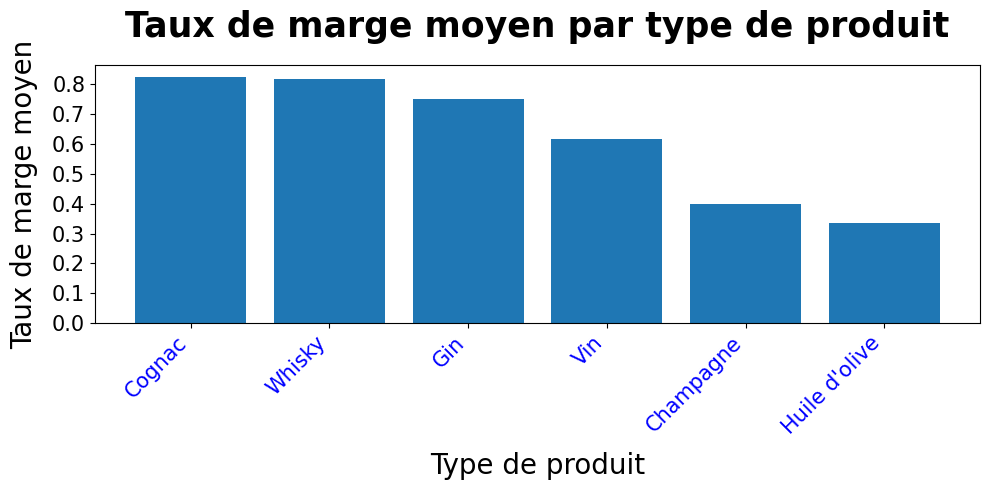

In [95]:
#Affichage dans un graphique du taux de marge par type de produit
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.bar(df_marge_moyenne_type['product_type'],df_marge_moyenne_type['taux_marge'])
plt.title("Taux de marge moyen par type de produit",fontsize=25,pad=20, fontweight='bold')
plt.xlabel("Type de produit",fontsize=20,labelpad=10)
plt.ylabel("Taux de marge moyen",fontsize=20,labelpad=10)
plt.xticks(rotation=45, ha='right',color='blue',fontsize=15)
plt.yticks(fontsize=15)
plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.5 - Analyse des corrélations entre les variables stock, sales et price</h3>
</div>

In [96]:
############################
# Analyse des corrélations #
############################

#Importation de Seaborn
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
#Création d'une heatmap de corrélation avec les variables stock, sales et price
df_corr = df_merge[['stock_quantity', 'total_sales', 'price']]
# Calcul de la matrice de corrélation
corr_matrix = df_corr.corr()
corr_matrix

,stock_quantity,total_sales,price
stock_quantity,1.000000,0.452943,-0.103621
total_sales,0.452943,1.000000,-0.519813
price,-0.103621,-0.519813,1.000000


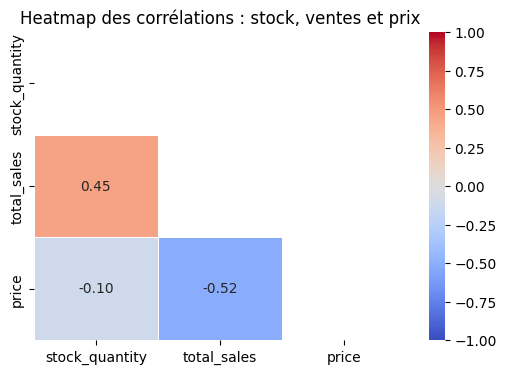

In [97]:
# Création d'un mask pour n'afficher qu'une demi-heatmap La matrice de corrélation est symétrique
# sert à supprimer l’information redondante et à rendre la heatmap plus lisible
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
# Création de la heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix,mask=mask,annot=True,fmt=".2f",cmap="coolwarm",linewidths=0.5, vmin=-1,vmax=1)
plt.title("Heatmap des corrélations : stock, ventes et prix")
plt.show()

In [98]:
#Que peut-on conclure des corrélations ?

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.6 - Mise à disposition de la nouvelle table sur un fichier Excel</h3>
</div>

In [99]:
#Mettre le dataset df_merge sur un fichier Excel
#from google.colab import files
#files.download("df_merge.xlsx")
#Cette étape peut être utile pour partager le résultat du dataset obtenu avec les équipes.
